In [3]:
from utils.binaries import *
from utils.plotting import *

set_plt_style('double tex')

17:22:01 (   +9.9s) [DEBUG  ] -- font size set to 9.5
17:22:01 (    +1ms) [DEBUG  ] -- label size set to 13.0
17:22:01 (    +0ms) [DEBUG  ] -- figure size set to [3.3, 2.5]
17:22:01 (    +1ms) [DEBUG  ] -- markersize set to 2.0
17:22:01 (    +0ms) [DEBUG  ] -- usetex set to True
17:22:01 (    +1ms) [DEBUG  ] -- label size set to 13.0
17:22:01 (    +0ms) [DEBUG  ] -- figure size set to [3.3, 2.5]
17:22:01 (    +1ms) [DEBUG  ] -- markersize set to 2.0
17:22:01 (    +0ms) [DEBUG  ] -- usetex set to True


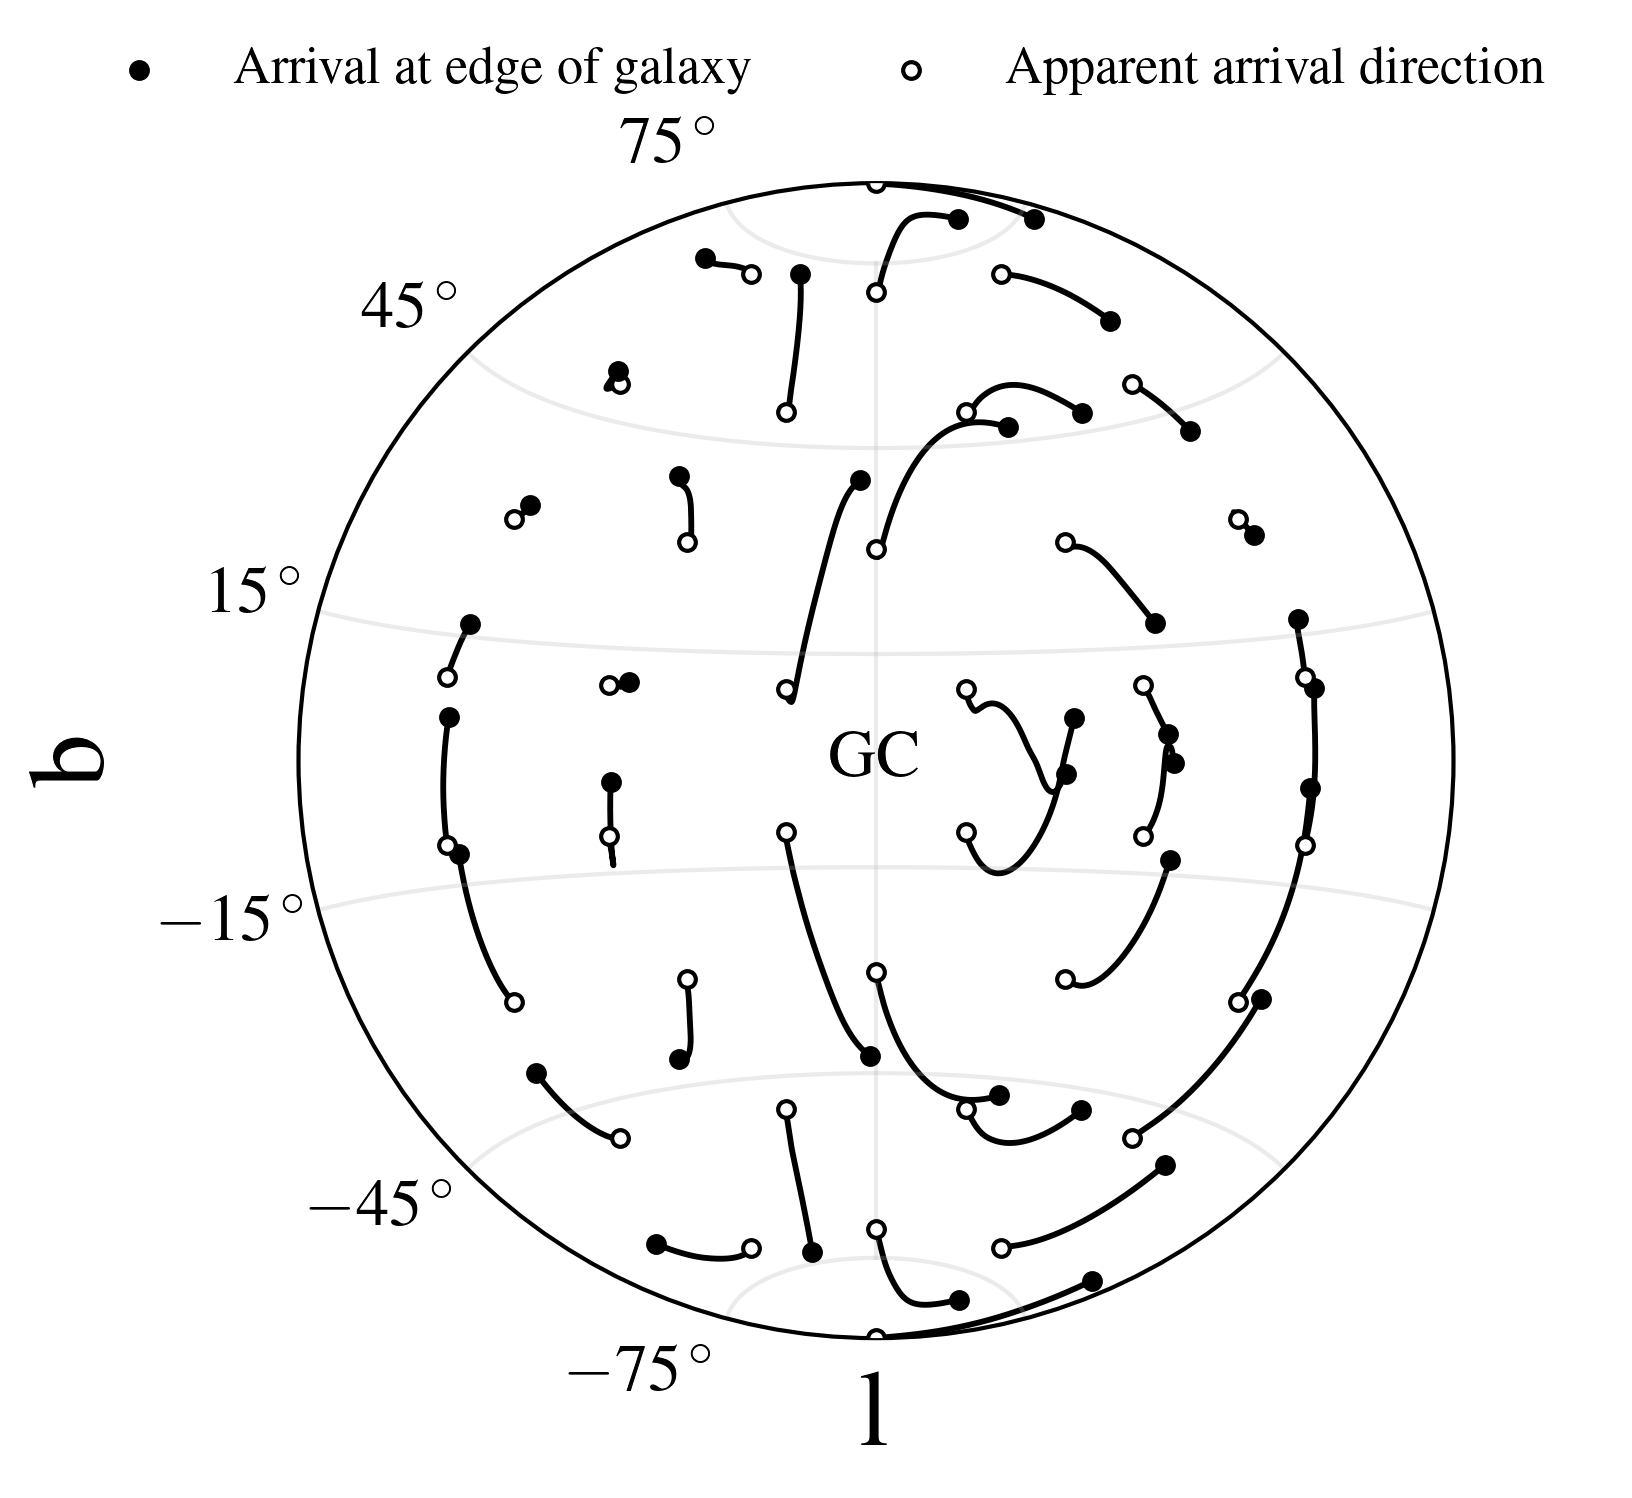

In [21]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='hammer')
ax.set_aspect("equal")

N_b = 10
N_l = {
    90: 3,
    70: 5,
    50: 6,
    30: 7,
    10: 8,
}

extract = lambda x: (x[0] * np.pi/180, x[-1] * np.pi/180)

for b_in in np.linspace(-90, 90, N_b, endpoint=True):
    for l_in in np.linspace(-180, 180, N_l[np.abs(b_in)], endpoint=True)[1:-1]:

        l, b = np.loadtxt(f"home/quizznor/distortion_maps/{l_in}_{b_in}.csv", unpack=True)
        l, b = l * np.pi/180, b * np.pi/180

        ax.plot(l, b, lw=0.7, c='k', zorder=0, marker='none', ls='-')
        ax.scatter(l[0], b[0], fc='w', ec='k', zorder=10, lw=0.5)
        ax.scatter(l[-1], b[-1], c='k', zorder=10, lw=0.5)

ax.set_ylabel("b")
ax.set_xlabel("l")
ax.scatter([], [], fc='k', ec='k', label='Arrival at edge of galaxy', lw=0.5)
ax.scatter([], [], fc='w', ec='k', label='Apparent arrival direction', lw=0.5)

ax.text(0, 0, "GC", ha='center', va='center', fontsize=8, color='k')
_ = y_ticklabels = np.array([fr"${d}\,^\circ$" for d in range(-75, 76, 30)])
ax.set_yticks(ax.get_yticks()[::2], y_ticklabels, fontsize=8)
ax.set_xticks([0], [""], fontsize=8)
ax.grid(True, alpha=0.25)
fig.legend(loc="outside upper center", ncol=2, fontsize=6.3)